![IRISCC Logo](Resources/iriscc_logo.png)

<span style="color: steelblue; font-size: 36px; font-weight: bold;">
Risk on Human Health in Urban Areas during Heatwaves Associated with Deteriorated Air Quality
</span>
<br><br>
<span style="color: black; font-size: 26px; font-weight: bold;">
Demonstrator 1: Exposure Linking Notebook 
</span>

## Background

Summer in Europe is increasingly marked by two overlapping risks: extreme heat and poor air quality (AQ). Together, these hazards can be detrimental to human health.

This notebook shows how to connect **climate data**, **air-quality measurements**, and **address-level health data** in a practical way. 

We will link individual health records to weather and air-quality data at the same location and time. That makes it possible to study how heatwaves and pollution interact in urban environments.

## Step 1 — Cohort data

First, load the subject-level dataset. This synthetic dataset contains 20 individuals, each with a residential location in the Netherlands.  
Each individual has a fictional Health Score, which is a stand-in for any real health metric of interest.

<div style="margin-top:0.75rem; padding:0.8rem 0.95rem; border-left: 4px solid #1f4e79; border-radius: 8px; background: rgba(31, 78, 121, 0.08);">
  <span style="display:block; color:#1f4e79; font-size:0.75rem; font-weight:700; letter-spacing:0.12em; text-transform:uppercase; margin-bottom:0.35rem;"></span>
  <span style="color:#1f4e79;">Run the cell below and scroll down to view the subjects table and plot the locations on a map.</span>
</div>

SubjectID,Health score,Residential_Location
1,0.87,POINT (3984469.052 3226669.706)
2,0.56,POINT (3986650.898 3227931.398)
3,0.13,POINT (3950616.501 3209204.081)
4,0.45,POINT (3934813.035 3233868.721)
5,0.76,POINT (3933206.687 3231621.668)
...,...,...
16,0.72,POINT (4108906.303 3239047.999)
17,0.91,POINT (4093721.041 3254875.218)
18,0.76,POINT (3944418.615 3242443.784)
19,0.31,POINT (3950287.86 3252441.922)

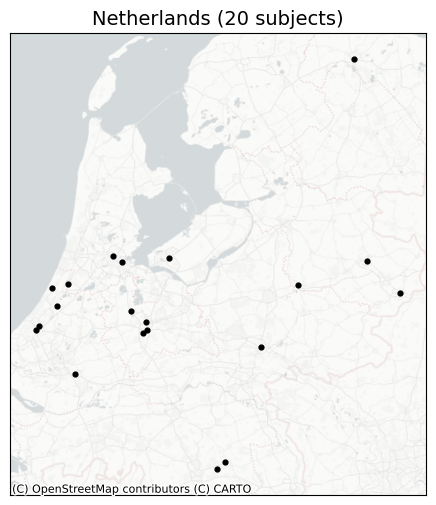

In [17]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import contextily as ctx
from IPython.display import display, HTML
import io
import base64

path = "Resources/netherlands_addresses.gpkg"
location_gdf = gpd.read_file(path)

# Reorder columns
cols = location_gdf.columns.tolist()
if 'SubjectID' in cols:
    cols.insert(0, cols.pop(cols.index('SubjectID')))
    location_gdf = location_gdf[cols]

location_gdf = location_gdf.rename_geometry("Residential_Location")

fig, ax = plt.subplots(figsize=(8, 6))

gdf_plot = location_gdf.to_crs(epsg=3857)
gdf_plot.plot(ax=ax, markersize=12, color='black', alpha=1.0)

ax.set_xlim(gdf_plot.total_bounds[0] - 20000, gdf_plot.total_bounds[2] + 20000)
ax.set_ylim(gdf_plot.total_bounds[1] - 20000, gdf_plot.total_bounds[3] + 20000)

ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.PositronNoLabels,
    crs=gdf_plot.crs
)

if 'name' in gdf_plot.columns and gdf_plot.geometry.geom_type.isin(['Point']).all():
    for x, y, label in zip(gdf_plot.geometry.x, gdf_plot.geometry.y, gdf_plot['name']):
        ax.annotate(
            str(label),
            xy=(x, y),
            xytext=(2, 2),
            textcoords='offset points',
            fontsize=9,
            color='black',
            alpha=0.95,
            path_effects=[pe.withStroke(linewidth=2, foreground='white')]
        )

ax.set_title(f"Netherlands ({len(gdf_plot)} subjects)", fontsize=14)
ax.set_xticks([])
ax.set_yticks([])

buf = io.BytesIO()
plt.savefig(buf, format='png', bbox_inches='tight')
plt.close(fig)
img_base64 = base64.b64encode(buf.getvalue()).decode()

table_html = location_gdf.to_html(max_rows=10, index=False)
table_html = table_html.replace(
    "<table",
    '<table style="display:block; overflow-y:auto; max-height:400px;"'
)

html = f"""
<div style="display:flex; gap:20px; align-items:flex-start;">
    <div style="flex:1; min-width:400px;">
        {table_html}
    </div>
    <div style="flex:1;">
        <img src="data:image/png;base64,{img_base64}" style="max-width:100%; height:auto;">
    </div>
</div>
"""

display(HTML(html))

## Step 2 — Air quality and weather data

Fine-resolution data has been modeled for many major exposome factors, including air pollution and weather [1].  
Open data platforms facilitate access to these datasets for research into the health impacts of environmental exposures.  
One place to find modeled air pollution data for all of Europe is the Exposome Maps Platform (https://exposome.uu.nl/).

  
For this demonstrator, we will consider the following datasets from the Exposome Maps Platform:

**Air Quality**:  
*These datasets are annual averages for the year 2020, at a spatial resolution of 25m x 25m.*
- PM10 concentrations
- PM2.5 concentrations
- O3 concentrations
- NO2 concentrations

*These datasets are annual averages for the year 2010, at a spatial resolution of 100m x 100m.*
- Black Carbon concentrations

**Weather**:  
*The following weather datasets enable linking to temperature at different temporal scales, from which definitions of heatwaves can be derived. They have a 1km x 1km resolution:*
- Annual mean temperature *(2020)*
- Monthly mean temperature *(December 2020)*
- Daily mean temperature *(December 31st, 2020)*
- Daily minimum temperature *(December 31st, 2020)*
- Daily maximum temperature *(December 31st, 2020)*

<br><br>
Visit the Exposome Maps Platform to visualize these datasets (and more) over all of Europe.
<br><br>
<div style="margin-top:0.75rem; padding:0.8rem 0.95rem; border-left: 4px solid #1f4e79; border-radius: 8px; background: rgba(31, 78, 121, 0.08);">
  <span style="display:block; color:#1f4e79; font-size:0.75rem; font-weight:700; letter-spacing:0.12em; text-transform:uppercase; margin-bottom:0.35rem;"></span>
  <span style="color:#1f4e79;">In the cell below, select the exposure and weather variables that you want to link to locations.
You can do this by uncommenting the lines that correspond to the datasets you want to use. Then run the cell.</span>
</div>

In [86]:
### INSTRUCTIONS 1: Uncomment (remove the #) in front of the air quality datasets you want to include in your analysis.
exposure_datasets = [
    "PM10",
    "PM2.5",
    "O3",
    # "NO2",
    # "Annual mean Black Carbon concentrations"
]

### INSTRUCTIONS 2: Uncomment (remove the #) in front of the weather datasets you want to include in your analysis.
weather_datasets = [
    "Annual mean temperature",
    "Monthly mean temperature",
    # "Daily average temperature",
    # "Daily minimum temperature",
    # "Daily maximum temperature"
]

if not exposure_datasets or not weather_datasets:
    print("Please select at least one exposure dataset and one weather dataset by uncommenting them in the code.")
    
else:
    print("Selected exposure datasets:")
    for dataset in exposure_datasets:
        print(f" - {dataset}")

    print("\nSelected weather datasets:")
    for dataset in weather_datasets:
        print(f" - {dataset}")

Selected exposure datasets:
 - PM10
 - PM2.5
 - O3

Selected weather datasets:
 - Annual mean temperature
 - Monthly mean temperature


## Step 3 — Link Locations to Exposure Data

Since these are **raster datasets**, values can be directly extracted at each address location.  
This is typically done using GIS tools or Python geospatial libraries.  
Note that the spatial resolution of the raster data affects the precision of the exposure estimates at each location.

<div style="margin-top:0.75rem; padding:0.8rem 0.95rem; border-left: 4px solid #1f4e79; border-radius: 8px; background: rgba(31, 78, 121, 0.08);">
  <span style="display:block; color:#1f4e79; font-size:0.75rem; font-weight:700; letter-spacing:0.12em; text-transform:uppercase; margin-bottom:0.35rem;"></span>
  <span style="color:#1f4e79;">Run the cell below to link the selected exposures and weather datasets to the address points in the subjects dataset (it may take a few moments to run).</span>
</div>



In [87]:
from beacon_api import *
from collections import namedtuple
import geopandas as gpd
import numpy as np

client = Client("https://beacon-iriscc.maris.nl")

exposure_tuple = namedtuple("Exposure", ["file", "parameter", "value_column", "resolution"])
exposures_dict = {
    "NO2": exposure_tuple("NL_points_25m.gpkg", "no2", "no2", 25),
    "PM10": exposure_tuple("NL_points_25m.gpkg", "pm10", "pm10", 25),
    "PM2.5": exposure_tuple("NL_points_25m.gpkg", "pm25", "pm25", 25),
    "O3": exposure_tuple("NL_points_25m.gpkg", "o3", "o3", 25),
    "Annual mean Black Carbon concentrations": exposure_tuple("NL_points_100m.gpkg", "annual_mean_black_carbon", "bc", 1000),
    "Annual mean temperature": exposure_tuple("NL_points_1_km.gpkg", "annual_mean_temperature", "temperature", 1000),
    "Monthly mean temperature": exposure_tuple("NL_points_1_km.gpkg", "monthly_mean_temperature", "temperature", 1000),
    "Daily average temperature": exposure_tuple("NL_points_1_km.gpkg", "daily_mean_temperature", "temperature", 1000),
    "Daily minimum temperature": exposure_tuple("NL_points_1_km.gpkg", "daily_min_temperature", "temperature", 1000),
    "Daily maximum temperature": exposure_tuple("NL_points_1_km.gpkg", "daily_max_temperature", "temperature", 1000)
}

tables = client.list_tables()

linked_location_gdf = location_gdf.copy()
linked_location_gdf["linking_id"] = location_gdf.index

def fetch_and_join(dataset_name, linked_location_gdf):
    file = exposures_dict.get(dataset_name).file
    parameter = exposures_dict.get(dataset_name).parameter
    if not parameter:
        return linked_location_gdf  # skip silently

    value_col = exposures_dict.get(dataset_name).parameter
    resolution = exposures_dict.get(dataset_name).resolution

    # Fetch exposure data
    data_gdf = gpd.read_file("Resources/" + file)
    exposure_lookup = data_gdf[["geometry", value_col]].copy()

    # Find nearest exposure point for each location
    closest = gpd.sjoin_nearest(
        linked_location_gdf,
        exposure_lookup,
        how="left",
        distance_col="distance",
        max_distance=resolution
    )

    merged = linked_location_gdf.merge(
        closest[["linking_id", value_col]],
        on="linking_id",
        how="left"
    )
    merged = merged.rename(columns={value_col: dataset_name})
    merged[dataset_name] = merged[dataset_name].apply(lambda x: round(x, 2))
    # merged.drop(columns=["linking_id"], inplace=True)
    return merged

# # Run pipeline
for dataset in exposure_datasets + weather_datasets:
    linked_location_gdf = fetch_and_join(dataset, linked_location_gdf)

linked_location_gdf.drop(columns=["linking_id"], inplace=True)
display(linked_location_gdf)


Connected to: https://beacon-iriscc.maris.nl/ server successfully
Beacon Version: 1.6.0


,SubjectID,Health score,Residential_Location,PM10,PM2.5,O3,Annual mean temperature,Monthly mean temperature
0,1,0.87,POINT (3984469.052 3226669.706),18.13,10.42,65.63,12.04,17.15
1,2,0.56,POINT (3986650.898 3227931.398),17.25,9.86,63.19,12.18,17.46
2,3,0.13,POINT (3950616.501 3209204.081),17.63,9.78,66.10,12.26,17.48
3,4,0.45,POINT (3934813.035 3233868.721),15.98,9.41,64.89,12.25,17.46
4,5,0.76,POINT (3933206.687 3231621.668),17.20,10.05,64.52,12.27,17.35
5,6,0.21,POINT (3972890.801 3264338.014),18.88,9.66,60.24,12.18,17.33
6,7,0.47,POINT (3976811.887 3261268.45),17.14,9.95,63.29,12.13,17.21
7,8,0.91,POINT (3999352.46 3261844.256),17.80,9.20,67.21,11.84,17.36
8,9,0.62,POINT (3979727.935 3237734.819),17.14,9.56,66.02,11.60,16.59
9,10,0.71,POINT (3986272.965 3231975.387),17.68,9.75,63.68,12.20,17.44


We get a table where each row corresponds to an individual, and the columns include their Health Score, location, and linked values for exposures and weather. This dataset can now be used for analysis of how environmental factors relate to health outcomes.

<div style="margin-top:0.75rem; padding:0.8rem 0.95rem; border-left: 4px solid #1f4e79; border-radius: 8px; background: rgba(31, 78, 121, 0.08);">
  <span style="display:block; color:#1f4e79; font-size:0.75rem; font-weight:700; letter-spacing:0.12em; text-transform:uppercase; margin-bottom:0.35rem;"></span>
  <span style="color:#1f4e79;">Run the cell below to visualize the values on a map.</span>
</div>


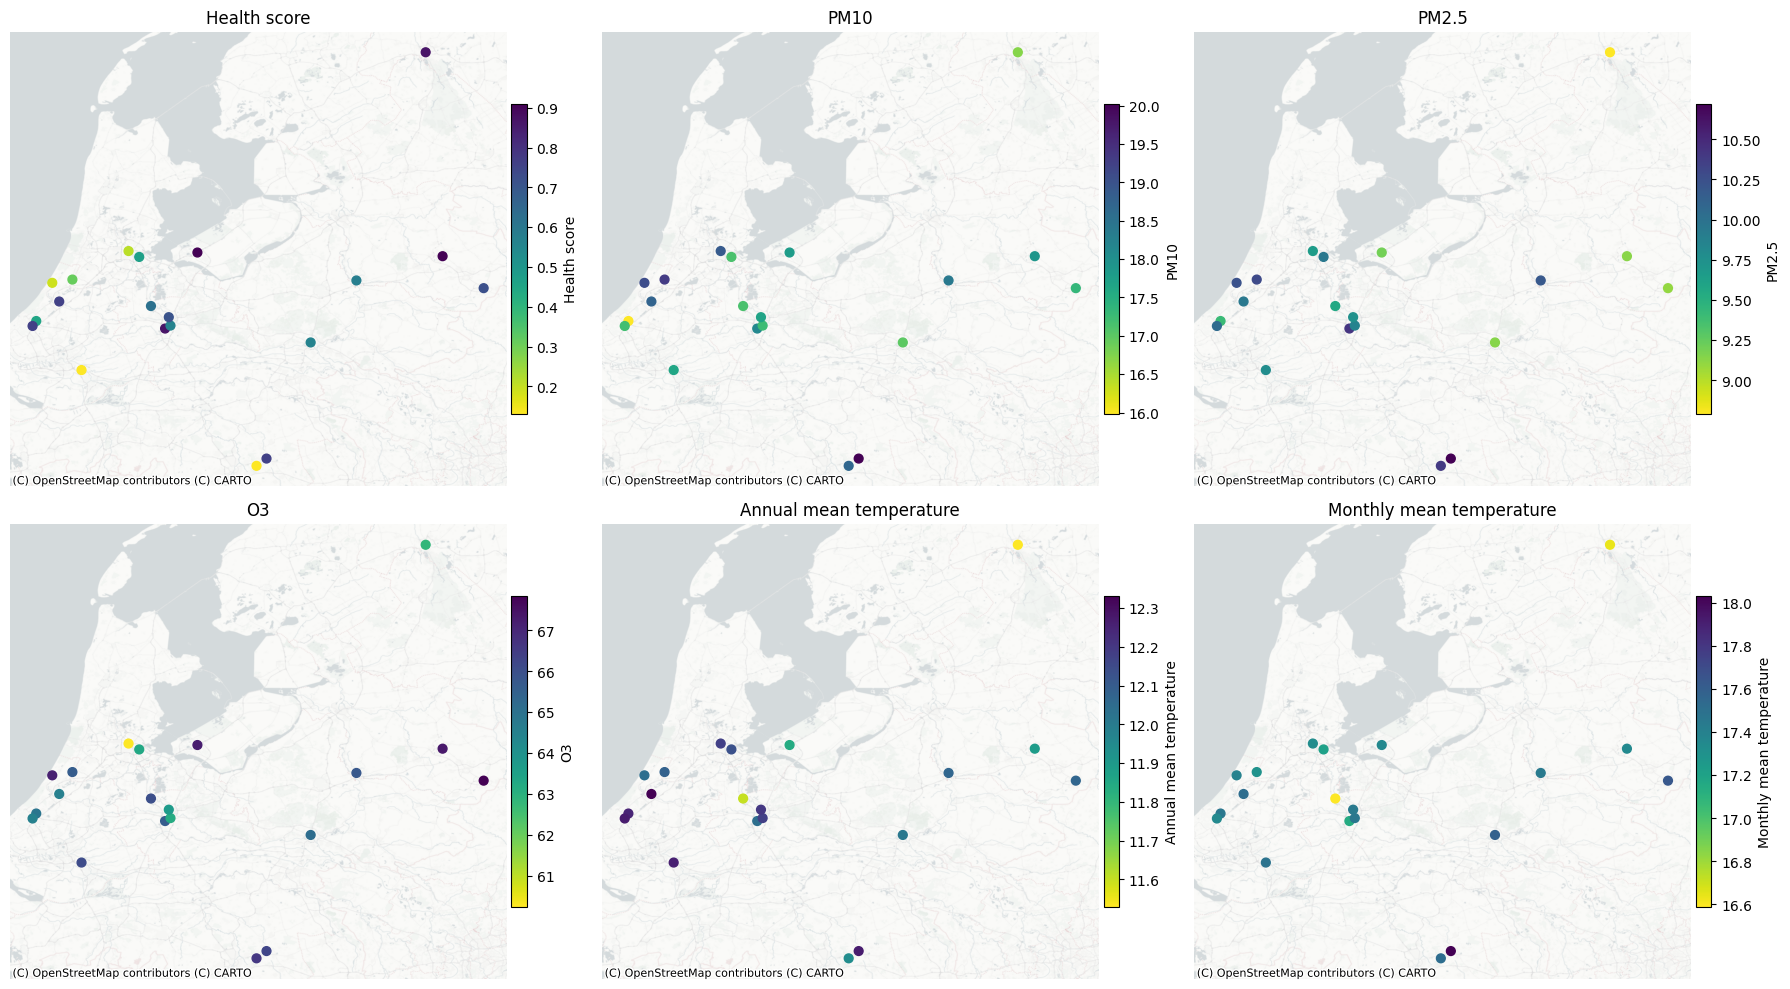

In [88]:
linked_location_gdf = linked_location_gdf.to_crs(epsg=3857)

# Columns you want to plot (exclude non-numeric / IDs / geometry)
exclude_cols = ["SubjectID", "geometry", "Residential_Location"]
plot_cols = [col for col in linked_location_gdf.columns if col not in exclude_cols]

# Grid layout (adjust depending on number of variables)
n_cols = 3
n_rows = int(np.ceil(len(plot_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(plot_cols):
    ax = axes[i]

    # Consistent color scale per variable
    vmin = linked_location_gdf[col].min()
    vmax = linked_location_gdf[col].max()

    sc = ax.scatter(
        linked_location_gdf.geometry.x,
        linked_location_gdf.geometry.y,
        c=linked_location_gdf[col],
        cmap="viridis_r",
        s=40,
        alpha=1,
        vmin=vmin,
        vmax=vmax
    )

    # Add basemap
    ctx.add_basemap(
        ax,
        source=ctx.providers.CartoDB.PositronNoLabels,
        crs=linked_location_gdf.crs
    )

    ax.set_title(col)
    ax.set_axis_off()

    # Add colorbar per subplot
    cbar = plt.colorbar(sc, ax=ax, fraction=0.03, pad=0.01)
    cbar.set_label(col)

# Remove empty subplots if any
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Step 4 — Use for analysis

The linking process can be the basis for a variety of analyses. Here are a few examples:


* Baranyi, G., Harron, K., Shen, Y. et al. studied the relationship between **early life course air pollution exposure** and **general health** in adolescence in the United Kingdom.
They linked air pollution exposure to buffers around postcode centroids over the life course of participants. Annual averages of PM2.5, PM10, and NO2
were used to calculate mean exposures during different life stages, then compared to self-reported general health and hospital episodes [2]. 
 


* In the Netherlands, a **heatwave** is defined as a period of at least 5 consecutive days with maximum temperatures exceeding 25°C, including at least 3 days with maximum temperatures exceeding 30°C (as measured at a weather station in De Bilt) [3]. Several studies have shown that heatwaves in Europe lead not only to health consequences but also to excessive deaths [4]. We can use a stack of **daily maximum temperature** data to derive heatwave periods and identify which individuals were exposed. This allows us to build models that assess the impact of heatwaves on a variety of health outcomes, such as hospital admissions or mortality rates, while also considering air quality as a potential confounder.

* The RI-URBANS pilot study aimed to assess the short-term associations between a large number of **novel air pollutant**s (97 PM-related pollutants) and **mortality** in four pilot cities: Athens, Barcelona, Paris, and Zurich. A harmonised air pollution data collection protocol was established to obtain daily data from Air Quality Monitoring Networks (AQMNs) for a period of three years. Instead of linking to specific address points, the data were linked to city-wide daily mortality counts from public health databases. Time-series analyses were then conducted to investigate the associations between air pollution and mortality, highlighting the need for long-term daily monitoring of “novel” air pollutant metrics on multiple sites across the EU [5].

## References
[1] de Hoogh, K., Hoek, G., Flückiger, B., Bussalleu, A., Vienneau, D., Jeong, A., Probst-Hensch, N., de Pinho, M. G. M., Mackenbach, J. D., Lakerveld, J., Beulens, J. W., Castagné, R., Delpierre, C., Kelly-Irving, M., Shen, Y., Huss, A., Dadvand, P., Pradas, M. C., Nieuwenhuijsen, M., & Vlaanderen, J. (2025). A Europe-wide characterization of the external exposome: A spatio-temporal analysis. Environment International, 200, 109542. https://doi.org/10.1016/j.envint.2025.109542

[2] Baranyi, G., Harron, K., Shen, Y. et al. The relationship between early life course air pollution exposure and general health in adolescence in the United Kingdom. Sci Rep 15, 10983 (2025). https://doi.org/10.1038/s41598-025-94107-w

[3] https://www.rivm.nl/en/heat/national-heatwave-plan

[4] Ahmed, I., Van Esch, M., & Van Der Hoeven, F. (2023). Heatwave vulnerability across different spatial scales: Insights from the Dutch built environment. Urban Climate, 51, 101614. https://doi.org/10.1016/j.uclim.2023.101614

[5] https://riurbans.eu/wp-content/uploads/2025/07/RI-URBANS_D31_D4_10-1.pdf